### NASDAQ Return Forecasting, Volatility Modeling, and VaR Backtesting

Number of observations: 13822


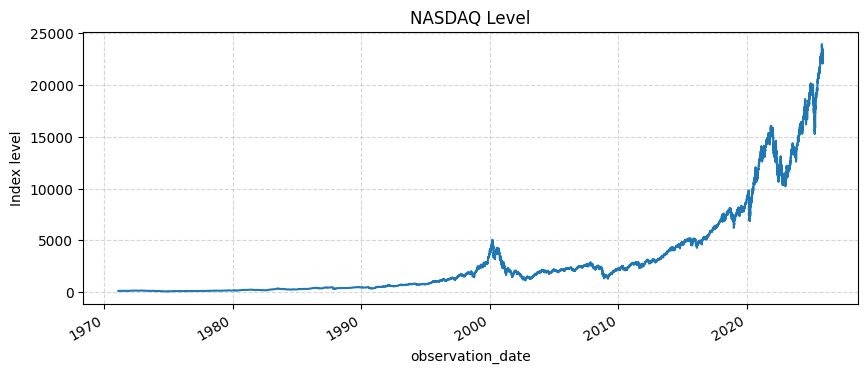

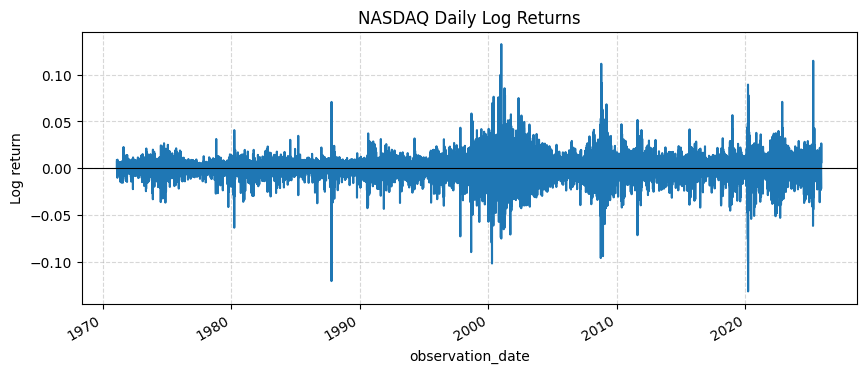

Sample mean      : 0.000394606309243955
Sample variance  : 0.00016291484550248124
Sample skewness  : -0.32690946381653097
Excess kurtosis  : 9.444869689442566
Kurtosis (3 + ex.): 12.444869689442566
Annualized mean (approx): 0.09944078992947666
Annualized st.dev (approx): 0.20261920211723586


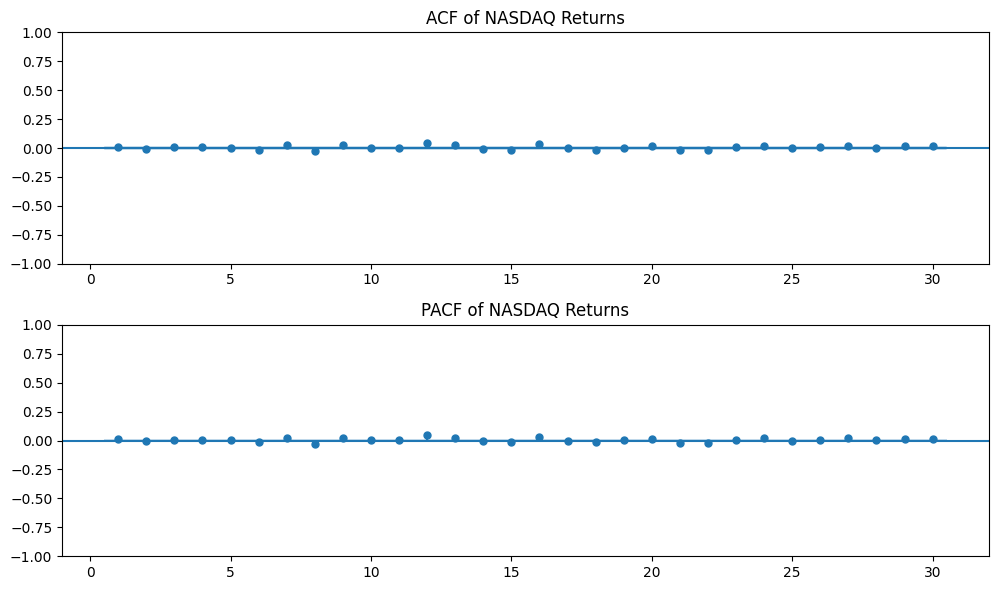


 Full Sample (1971–2025)  — Observations: 13821

Ljung–Box for RETURNS:
      lb_stat     lb_pvalue  p<0.05
10  32.740719  3.010996e-04    True
20  96.863210  4.568117e-12    True

Ljung–Box for ABSOLUTE RETURNS:
         lb_stat  lb_pvalue  p<0.05
10  15161.953306        0.0    True
20  25488.415896        0.0    True

Ljung–Box for SQUARED RETURNS:
         lb_stat  lb_pvalue  p<0.05
10   9578.018310        0.0    True
20  13732.180321        0.0    True

 Last 20 Years  — Observations: 5034

Ljung–Box for RETURNS:
       lb_stat     lb_pvalue  p<0.05
10   91.356963  2.881194e-15    True
20  126.975845  1.435924e-17    True

Ljung–Box for ABSOLUTE RETURNS:
        lb_stat  lb_pvalue  p<0.05
10  4122.831715        0.0    True
20  6398.839235        0.0    True

Ljung–Box for SQUARED RETURNS:
        lb_stat  lb_pvalue  p<0.05
10  3585.836794        0.0    True
20  4918.396527        0.0    True

 Last 10 Years  — Observations: 2516

Ljung–Box for RETURNS:
       lb_stat     lb_pvalue

In [11]:
# ---------- Question 1 ----------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (10, 4)
DEBUG = False  # Set True to see head/tail diagnostics.

# ---------- 1. Load FRED CSV and keep NASDAQ ----------
file_path = "fredgraph.csv"  # Change if your file is in another folder.

df_raw = pd.read_csv(file_path, parse_dates=["observation_date"])
df_raw = df_raw.set_index("observation_date").sort_index()

# Keep only NASDAQ, drop missing/duplicates, and coerce to numeric.
nasdaq = pd.to_numeric(df_raw["NASDAQCOM"], errors="coerce").dropna()
nasdaq = nasdaq[~nasdaq.index.duplicated(keep="first")]
print("Number of observations:", len(nasdaq))
if DEBUG:
    print(nasdaq.head())
    print(nasdaq.tail())

# ---------- 2. Compute log returns ----------
returns = np.log(nasdaq).diff().dropna()
returns.name = "NASDAQ_log_return"
if DEBUG:
    print(returns.head())
    print(returns.tail())

# ---------- 2a. Plot price level ----------
fig, ax = plt.subplots()
nasdaq.plot(ax=ax)
ax.set_title("NASDAQ Level")
ax.set_ylabel("Index level")
ax.grid(True, ls="--", alpha=0.5)
plt.show()

# ---------- 2b. Plot returns ----------
fig, ax = plt.subplots()
returns.plot(ax=ax)
ax.axhline(0, color="k", lw=0.8)
ax.set_title("NASDAQ Daily Log Returns")
ax.set_ylabel("Log return")
ax.grid(True, ls="--", alpha=0.5)
plt.show()

# ---------- 3. Sample statistics ----------
mean_ret = returns.mean()
var_ret = returns.var(ddof=1)  # Sample variance.
skew_ret = returns.skew()
excess_kurt_ret = returns.kurt()  # Excess kurtosis.
kurt_ret = excess_kurt_ret + 3  # Classical kurtosis.

print("Sample mean      :", mean_ret)
print("Sample variance  :", var_ret)
print("Sample skewness  :", skew_ret)
print("Excess kurtosis  :", excess_kurt_ret)
print("Kurtosis (3 + ex.):", kurt_ret)

# ---------- Annualized statistics (approx.) ----------
trading_days = 252
print("Annualized mean (approx):", mean_ret * trading_days)
print("Annualized st.dev (approx):", returns.std(ddof=1) * np.sqrt(trading_days))

# ---------- 4. ACF and PACF of returns ----------
max_lag = 30  # You can change this to 20 or 40.

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(returns, lags=max_lag, ax=ax[0], zero=False)
ax[0].set_title("ACF of NASDAQ Returns")

plot_pacf(returns, lags=max_lag, ax=ax[1], method="ywm", zero=False)
ax[1].set_title("PACF of NASDAQ Returns")

plt.tight_layout()
plt.show()

# ---------- 5. Ljung-Box tests ----------
# ---------- Compute Ljung-Box for a dataset ----------
def lb_tests(series, lags=[10, 20]):
    """Return LB results for returns, |returns|, returns^2"""
    lb_ret = acorr_ljungbox(series, lags=lags, return_df=True)
    lb_abs = acorr_ljungbox(np.abs(series), lags=lags, return_df=True)
    lb_sq = acorr_ljungbox(series**2, lags=lags, return_df=True)
    return lb_ret, lb_abs, lb_sq


def add_sig_flag(df):
    """Add a boolean column for p<0.05 significance."""
    df = df.copy()
    df["p<0.05"] = df["lb_pvalue"] < 0.05
    return df


# ---------- Subsample windows for robustness ----------
def subset_by_years(series, years):
    """Return last N years of data."""
    cutoff = series.index.max() - pd.DateOffset(years=years)
    return series[series.index >= cutoff]


windows = {
    "Full Sample (1971–2025)": returns,
    "Last 20 Years": subset_by_years(returns, 20),
    "Last 10 Years": subset_by_years(returns, 10),
    "Last 5 Years": subset_by_years(returns, 5),
}

# ---------- Run robustness checks ----------
for name, data in windows.items():
    print("\n==============================")
    print(f" {name}  — Observations: {len(data)}")
    print("==============================")

    lb_ret, lb_abs, lb_sq = lb_tests(data)

    print("\nLjung–Box for RETURNS:")
    print(add_sig_flag(lb_ret))

    print("\nLjung–Box for ABSOLUTE RETURNS:")
    print(add_sig_flag(lb_abs))

    print("\nLjung–Box for SQUARED RETURNS:")
    print(add_sig_flag(lb_sq))


13802 18
                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.409
Date:                Mon, 16 Mar 2026   Prob (F-statistic):              0.235
Time:                        21:44:19   Log-Likelihood:                 40611.
No. Observations:               13802   AIC:                        -8.122e+04
Df Residuals:                   13800   BIC:                        -8.120e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      3.607

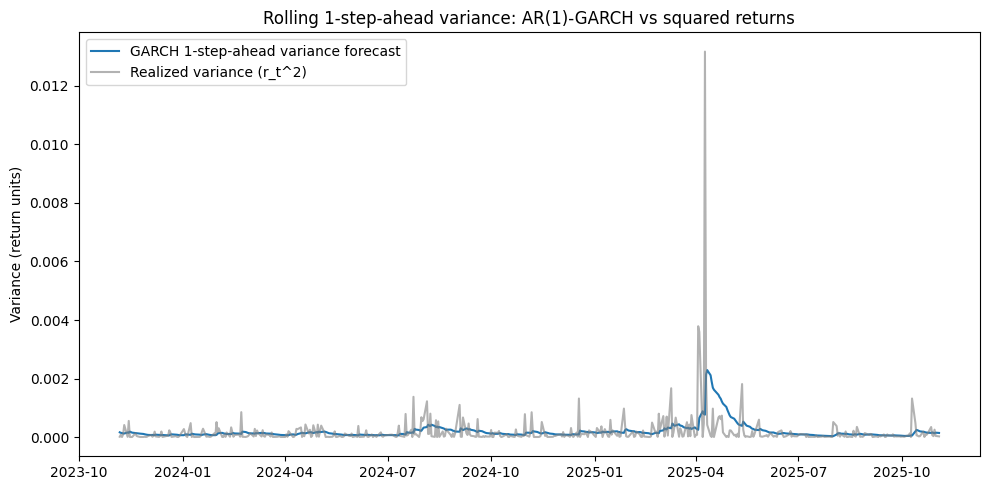

In [12]:
# ---------- Question 2 ----------
# ---------- 1. Prepare data and train/test split ----------
# Use the last 18 trading days for out-of-sample MSE.

import statsmodels.api as sm
from arch import arch_model

# Build lagged regressors
data = pd.DataFrame({"ret": returns})
data["lag1"] = data["ret"].shift(1)
data["lag1_sq"] = data["lag1"] ** 2  # kept for reference, unused below
data = data.dropna()

# Use last 18 obs as "most recent month" (cap at available length)
test_len = 18
n_test = min(test_len, len(data) - 1)
train = data.iloc[:-n_test].copy()
test = data.iloc[-n_test:].copy()
print(len(train), len(test))

def mse(actual, pred):
    return ((actual - pred) ** 2).mean()


# ---------- 2. Model 1: Linear AR(1) ----------
X_lin = sm.add_constant(train["lag1"])
y = train["ret"]

lin_res = sm.OLS(y, X_lin).fit()
print(lin_res.summary())

train["pred_lin_in"] = lin_res.fittedvalues
mse_lin_in = mse(train["ret"], train["pred_lin_in"])

X_test_lin = sm.add_constant(test["lag1"])
test["pred_lin"] = lin_res.predict(X_test_lin)
mse_lin = mse(test["ret"], test["pred_lin"])

sigma2_lin = lin_res.resid.var(ddof=1)
train["var_pred_lin"] = sigma2_lin
test["var_pred_lin"] = sigma2_lin
mse_lin_var_in = mse(train["ret"] ** 2, train["var_pred_lin"])
mse_lin_var = mse(test["ret"] ** 2, test["var_pred_lin"])

print("In-Sample MSE – AR(1) mean:", mse_lin_in)
print("Out-of-sample MSE – AR(1) mean:", mse_lin)
print("In-sample MSE – AR(1) variance:", mse_lin_var_in)
print("Out-of-sample MSE – AR(1) variance:", mse_lin_var)


# ---------- 3. TAR mean with regime-specific slopes ----------
# Regimes are based on the sign of lag1 (threshold at 0).
train["I_pos"] = (train["lag1"] > 0).astype(int)
test["I_pos"] = (test["lag1"] > 0).astype(int)

X_tar_train = sm.add_constant(
    pd.DataFrame(
        {
            "lag1_neg": train["lag1"] * (train["lag1"] <= 0),
            "lag1_pos": train["lag1"] * (train["lag1"] > 0),
            "I_pos": train["I_pos"],  # allows regime-specific intercept
        }
    )
)

tar_res = sm.OLS(train["ret"], X_tar_train).fit()
print(tar_res.summary())

train["pred_tar_in"] = tar_res.fittedvalues
mse_tar_in = mse(train["ret"], train["pred_tar_in"])

X_tar_test = sm.add_constant(
    pd.DataFrame(
        {
            "lag1_neg": test["lag1"] * (test["lag1"] <= 0),
            "lag1_pos": test["lag1"] * (test["lag1"] > 0),
            "I_pos": test["I_pos"],
        }
    )
)

test["pred_tar"] = tar_res.predict(X_tar_test)
mse_tar = mse(test["ret"], test["pred_tar"])

# Regime-specific variance (constant within each regime)
resid_tar = tar_res.resid
sigma2_tar_pos = resid_tar[train["I_pos"] == 1].var(ddof=1)
sigma2_tar_neg = resid_tar[train["I_pos"] == 0].var(ddof=1)

train["var_pred_tar"] = np.where(train["I_pos"] == 1, sigma2_tar_pos, sigma2_tar_neg)
test["var_pred_tar"] = np.where(test["I_pos"] == 1, sigma2_tar_pos, sigma2_tar_neg)

mse_tar_var_in = mse(train["ret"] ** 2, train["var_pred_tar"])
mse_tar_var = mse(test["ret"] ** 2, test["var_pred_tar"])

print("In-sample MSE – TAR (mean):", mse_tar_in)
print("Out-of-sample MSE – TAR (mean):", mse_tar)
print("In-sample MSE – TAR (variance):", mse_tar_var_in)
print("Out-of-sample MSE – TAR (variance):", mse_tar_var)

# ---------- 4. AR(1)-GARCH(1,1) with Student-t errors ----------
# Use proper expanding-window 1-step-ahead forecasting (no test leakage).

# Work in percent to match ARCH conventions.
train_ret_pct = train["ret"] * 100
test_ret_pct = test["ret"] * 100
full_ret_pct = data["ret"] * 100

# ---------- In-sample fit on TRAIN only ----------
am_train = arch_model(
    train_ret_pct,
    mean="AR",
    lags=1,
    vol="GARCH",
    p=1,
    q=1,
    dist="t",
)

res_train = am_train.fit(update_freq=0, disp="off")
print(res_train.summary())

# In-sample fitted mean on TRAIN
ar_params = res_train.params.filter(like="ar")
if ar_params.empty:
    ar_params = res_train.params.filter(like="ret[")

phi = ar_params.iloc[0]
const = res_train.params.get("Const", 0.0)

train_lag1_pct = train["lag1"] * 100
train_mean_in_pct = const + phi * train_lag1_pct
train_mean_in = train_mean_in_pct / 100.0
mse_garch_mean_in = mse(train["ret"], train_mean_in)

# In-sample conditional variance on TRAIN
train_cond_var_ret = (res_train.conditional_volatility ** 2) / 10000.0
mse_garch_var_in = mse(train["ret"] ** 2, train_cond_var_ret)

# ---------- Expanding-window 1-step-ahead forecasts for TEST ----------
garch_mean_fc = []
garch_var_fc = []

for i in range(len(test)):
    # Use only information available up to time t
    end_loc = len(train) + i
    hist_ret_pct = full_ret_pct.iloc[:end_loc]

    am_roll = arch_model(
        hist_ret_pct,
        mean="AR",
        lags=1,
        vol="GARCH",
        p=1,
        q=1,
        dist="t",
    )

    res_roll = am_roll.fit(update_freq=0, disp="off")

    fc = res_roll.forecast(horizon=1, reindex=False)

    mean_1 = fc.mean.iloc[-1, 0] / 100.0
    var_1 = fc.variance.iloc[-1, 0] / 10000.0

    garch_mean_fc.append(mean_1)
    garch_var_fc.append(var_1)

mean_fc_test = pd.Series(garch_mean_fc, index=test.index, name="pred_garch")
var_fc_test = pd.Series(garch_var_fc, index=test.index, name="var_pred_garch")

mse_garch = mse(test["ret"], mean_fc_test)
mse_garch_var = mse(test["ret"] ** 2, var_fc_test)

print("In-sample MSE – AR(1)-GARCH (mean):", mse_garch_mean_in)
print("Out-of-sample MSE – AR(1)-GARCH (mean):", mse_garch)
print("In-sample MSE – AR(1)-GARCH (variance):", mse_garch_var_in)
print("Out-of-sample MSE – AR(1)-GARCH (variance):", mse_garch_var)


# ---------- 5. Summary comparison table ----------
summary = pd.DataFrame(
    {
        "Model": ["AR(1)", "TAR (lag1>0)", "AR(1)-GARCH(1,1)"],
        "Test MSE (mean)": [mse_lin, mse_tar, mse_garch],
        "Train MSE (mean)": [mse_lin_in, mse_tar_in, mse_garch_mean_in],
        "Test MSE (var)": [mse_lin_var, mse_tar_var, mse_garch_var],
        "Train MSE (var)": [mse_lin_var_in, mse_tar_var_in, mse_garch_var_in],
    }
)
print("\n=== MSE summary (mean & variance) ===")
print(summary)

# ---------- Plot rolling 1-step-ahead variance forecasts (GARCH) vs squared returns ----------
# Use the rolling out-of-sample 1-step variance forecasts (return units).
var_fc_series = train_cond_var_ret.copy()
sq_returns = train["ret"] ** 2

# Align and take a recent window for clarity
window = 500  # change to, e.g., 250 to focus on the last 250 days
var_fc_plot = var_fc_series.dropna().iloc[-window:]
sq_ret_plot = sq_returns.loc[var_fc_plot.index]

plt.figure(figsize=(10, 5))
plt.plot(var_fc_plot.index, var_fc_plot, label="GARCH 1-step-ahead variance forecast")
plt.plot(sq_ret_plot.index, sq_ret_plot, color='gray', alpha=0.6, label="Realized variance (r_t^2)")
plt.title("Rolling 1-step-ahead variance: AR(1)-GARCH vs squared returns")
plt.ylabel("Variance (return units)")
plt.legend()
plt.tight_layout()
plt.show()


End-of-sample 5-step-ahead forecasts (daily return units):
            forecast_mean  forecast_variance  forecast_std_dev
2025-12-01       0.001678           0.000180          0.013429
2025-12-02       0.001057           0.000184          0.013572
2025-12-03       0.000977           0.000185          0.013605
2025-12-04       0.000966           0.000186          0.013635
2025-12-05       0.000965           0.000187          0.013666


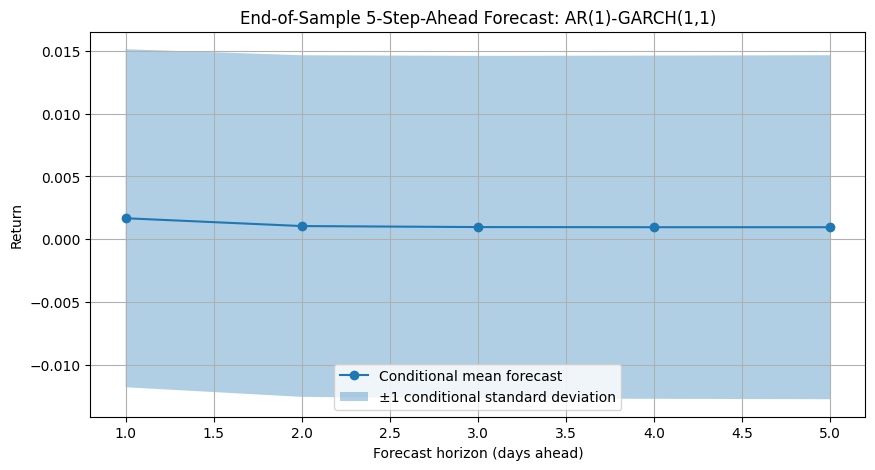

In [13]:
# ---------- End-of-sample 5-step-ahead forecasts from AR(1)-GARCH(1,1) ----------
# This is a final forecast generated using the full sample.
# It is for forward-looking illustration only, not for out-of-sample evaluation.

h = 5  # Forecast horizon in trading days.

am_full = arch_model(
    full_ret_pct,
    mean="AR",
    lags=1,
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

res_full = am_full.fit(update_freq=0, disp="off", show_warning=False)
fc = res_full.forecast(horizon=h, reindex=False)

# Extract the final forecast path (percent units), then convert to return units.
mean_5_pct = fc.mean.iloc[-1]  # h.1 ... h.h, percent returns
var_5_pct2 = fc.variance.iloc[-1]  # Forecast variance in percent-squared units.

mean_5_ret = mean_5_pct / 100.0
var_5_ret = var_5_pct2 / 10000.0
std_5_ret = np.sqrt(var_5_ret)

# Attach business-day dates after the last observation.
next_dates = pd.bdate_range(start=data.index[-1] + pd.Timedelta(days=1), periods=h)
mean_5_ret.index = next_dates
var_5_ret.index = next_dates
std_5_ret.index = next_dates

fc_table = pd.DataFrame({
    "forecast_mean": mean_5_ret,
    "forecast_variance": var_5_ret,
    "forecast_std_dev": std_5_ret
})

print("End-of-sample 5-step-ahead forecasts (daily return units):")
print(fc_table)

# Plot mean forecast path with +/-1 conditional standard deviation band.
horizon = np.arange(1, h + 1)

plt.figure(figsize=(10, 5))
plt.plot(horizon, mean_5_ret.values, marker="o", label="Conditional mean forecast")
plt.fill_between(
    horizon,
    mean_5_ret.values - std_5_ret.values,
    mean_5_ret.values + std_5_ret.values,
    alpha=0.35,
    label="±1 conditional standard deviation"
)
plt.title("End-of-Sample 5-Step-Ahead Forecast: AR(1)-GARCH(1,1)")
plt.xlabel("Forecast horizon (days ahead)")
plt.ylabel("Return")
plt.grid(True)
plt.legend()
plt.show()

| Date | mean | var | std |
| --- | --- | --- | --- |
| 2025-12-01 | 0.001678 | 0.000180 | 0.013429 |
| 2025-12-02 | 0.001057 | 0.000184 | 0.013572 |
| 2025-12-03 | 0.000977 | 0.000185 | 0.013605 |
| 2025-12-04 | 0.000966 | 0.000186 | 0.013635 |
| 2025-12-05 | 0.000965 | 0.000187 | 0.013666 |



=== AR(1) ===
Next-period mean: 0.000472
Next-period std:  0.012764
Parametric t skew/kurtosis: -0.029, 4.440
HS skew/kurtosis:           -0.315, 12.484

=== TAR ===
Next-period mean: 0.001024
Next-period std:  0.011243
Parametric t skew/kurtosis: 0.012, 4.305
HS skew/kurtosis:           -0.311, 12.395

=== AR(1)-GARCH(1,1)-t ===
Next-period mean: 0.001677
Next-period std:  0.013429
Estimated nu:     6.666
Parametric t skew/kurtosis: -0.010, 5.518
HS skew/kurtosis:           -0.599, 5.227


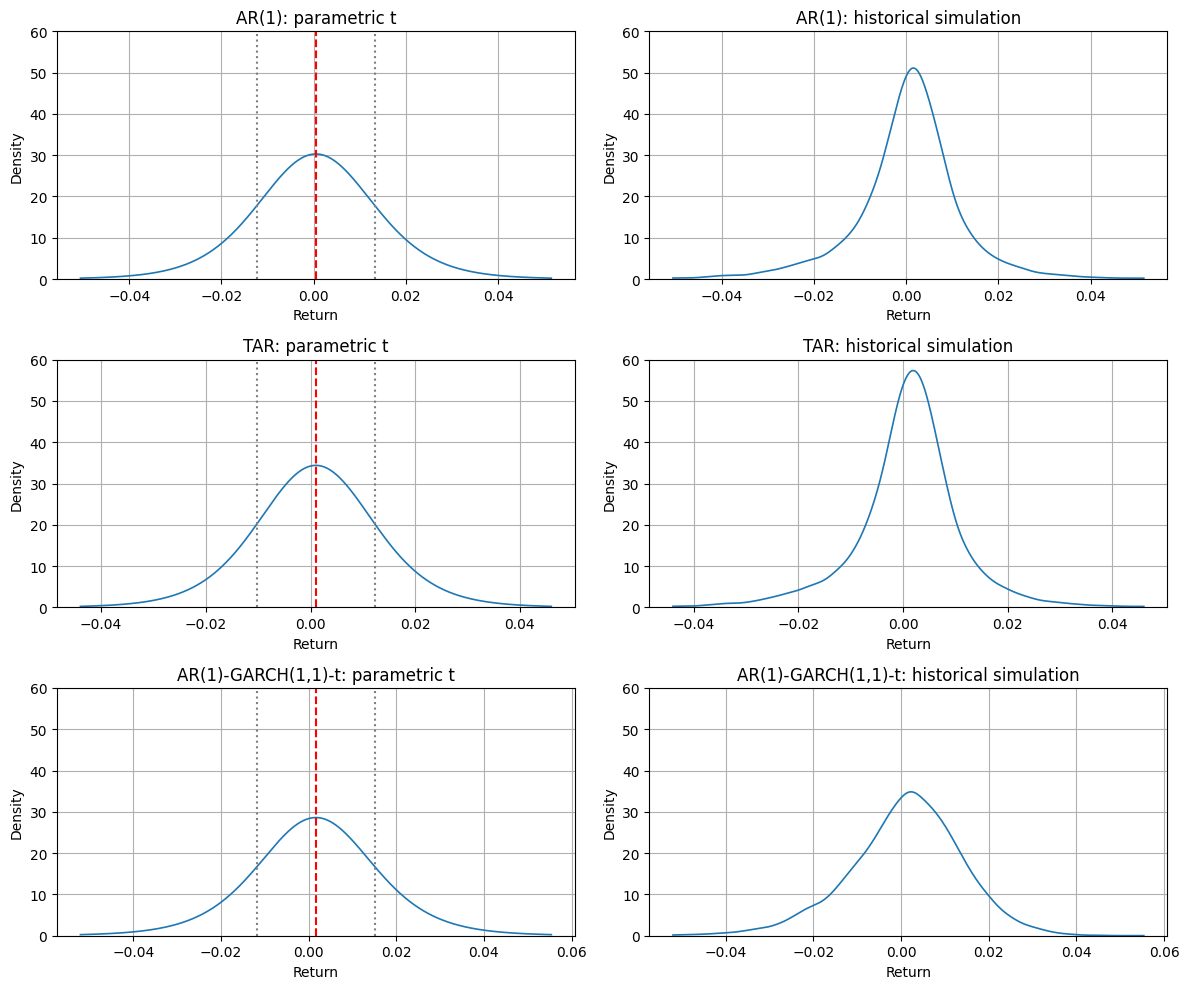

In [18]:
# ---------- Question 3: 1-step predictive distribution (parametric vs HS) ----------
# Compare AR(1), TAR, and AR(1)-GARCH(1,1)-t.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t as student_t, gaussian_kde, skew, kurtosis
import statsmodels.api as sm
from arch import arch_model

# ---------- Helpers ----------
rng = np.random.default_rng(42)

def make_grid(mu, sigma, width=4, n=2000):
    sigma_safe = max(float(sigma), 1e-8)
    return np.linspace(mu - width * sigma_safe, mu + width * sigma_safe, n)

def safe_kde(x, grid):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) < 10 or x.std(ddof=1) < 1e-12:
        return np.full_like(grid, np.nan, dtype=float)
    return gaussian_kde(x)(grid)

def sample_moments(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    return skew(x), kurtosis(x, fisher=False)

ret_q3 = returns.dropna()

# ---------- 1) AR(1) ----------
lag = ret_q3.shift(1).dropna()
ret_aligned = ret_q3.loc[lag.index]

X_lin = sm.add_constant(lag)
ols_lin = sm.OLS(ret_aligned, X_lin).fit()

# Build the next-period exogenous row using the last observed lag
last_lin = pd.DataFrame([[1.0, lag.iloc[-1]]], columns=X_lin.columns)
mu_lin = ols_lin.predict(last_lin).iloc[0]

sigma_lin = ols_lin.resid.std(ddof=int(ols_lin.df_model + 1))
sigma_lin = max(float(sigma_lin), 1e-8)

std_resid_lin = pd.Series(ols_lin.resid / sigma_lin).replace([np.inf, -np.inf], np.nan).dropna()

grid_lin = make_grid(mu_lin, sigma_lin)
pdf_lin_param = student_t.pdf((grid_lin - mu_lin) / sigma_lin, df=8) / sigma_lin
pdf_lin_hs = safe_kde(mu_lin + sigma_lin * std_resid_lin, grid_lin)

sim_lin = mu_lin + sigma_lin * student_t.rvs(df=8, size=50000, random_state=42)
lin_sk_param, lin_kt_param = sample_moments(sim_lin)
lin_sk_hs, lin_kt_hs = sample_moments(mu_lin + sigma_lin * std_resid_lin)

# ---------- 2) TAR (threshold on lag1 > 0) ----------
tar_df = pd.DataFrame({"ret": ret_aligned, "lag1": lag})
tar_df["I_pos"] = (tar_df["lag1"] > 0).astype(int)

X_tar = pd.DataFrame({
    "const": 1.0,
    "lag1_neg": tar_df["lag1"] * (tar_df["lag1"] <= 0),
    "lag1_pos": tar_df["lag1"] * (tar_df["lag1"] > 0),
    "I_pos": tar_df["I_pos"],
})

tar_res = sm.OLS(tar_df["ret"], X_tar).fit()
resid_tar = tar_res.resid

sigma_tar_pos = resid_tar[tar_df["I_pos"] == 1].std(ddof=1)
sigma_tar_neg = resid_tar[tar_df["I_pos"] == 0].std(ddof=1)
sigma_tar_pos = max(float(sigma_tar_pos), 1e-8)
sigma_tar_neg = max(float(sigma_tar_neg), 1e-8)

# Build true next-period regressor row from the last observed lag
last_lag = tar_df["lag1"].iloc[-1]
last_I_pos = int(last_lag > 0)

X_tar_next = pd.DataFrame({
    "const": [1.0],
    "lag1_neg": [last_lag if last_lag <= 0 else 0.0],
    "lag1_pos": [last_lag if last_lag > 0 else 0.0],
    "I_pos": [last_I_pos],
})

mu_tar = tar_res.predict(X_tar_next).iloc[0]
last_sigma_tar = sigma_tar_pos if last_I_pos == 1 else sigma_tar_neg

std_resid_tar = pd.Series(resid_tar / resid_tar.std(ddof=1)).replace([np.inf, -np.inf], np.nan).dropna()

grid_tar = make_grid(mu_tar, last_sigma_tar)
pdf_tar_param = student_t.pdf((grid_tar - mu_tar) / last_sigma_tar, df=8) / last_sigma_tar
pdf_tar_hs = safe_kde(mu_tar + last_sigma_tar * std_resid_tar, grid_tar)

sim_tar = mu_tar + last_sigma_tar * student_t.rvs(df=8, size=50000, random_state=43)
tar_sk_param, tar_kt_param = sample_moments(sim_tar)
tar_sk_hs, tar_kt_hs = sample_moments(mu_tar + last_sigma_tar * std_resid_tar)

# ---------- 3) AR(1)-GARCH(1,1)-t ----------
# Use a genuine 1-step-ahead forecast for predictive mean/variance.
ret_pct = ret_q3 * 100

am_q3 = arch_model(
    ret_pct,
    mean="AR",
    lags=1,
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)

res_q3 = am_q3.fit(update_freq=0, disp="off", show_warning=False)
nu_q3 = float(res_q3.params["nu"])

# One-step-ahead forecast from end of sample
fc_q3 = res_q3.forecast(horizon=1, reindex=False)
mu_hat = fc_q3.mean.iloc[-1, 0] / 100.0
sigma_hat = np.sqrt(fc_q3.variance.iloc[-1, 0] / 10000.0)

sigma_hat = max(float(sigma_hat), 1e-8)

grid_garch = make_grid(mu_hat, sigma_hat)
pdf_garch_param = student_t.pdf((grid_garch - mu_hat) / sigma_hat, df=nu_q3) / sigma_hat

std_resid_garch = pd.Series(res_q3.std_resid).replace([np.inf, -np.inf], np.nan).dropna()
pdf_garch_hs = safe_kde(mu_hat + sigma_hat * std_resid_garch, grid_garch)

sim_garch = mu_hat + sigma_hat * student_t.rvs(df=nu_q3, size=50000, random_state=44)
garch_sk_param, garch_kt_param = sample_moments(sim_garch)
garch_sk_hs, garch_kt_hs = sample_moments(mu_hat + sigma_hat * std_resid_garch)

# ---------- Print summaries ----------
print("\n=== AR(1) ===")
print(f"Next-period mean: {mu_lin:.6f}")
print(f"Next-period std:  {sigma_lin:.6f}")
print(f"Parametric t skew/kurtosis: {lin_sk_param:.3f}, {lin_kt_param:.3f}")
print(f"HS skew/kurtosis:           {lin_sk_hs:.3f}, {lin_kt_hs:.3f}")

print("\n=== TAR ===")
print(f"Next-period mean: {mu_tar:.6f}")
print(f"Next-period std:  {last_sigma_tar:.6f}")
print(f"Parametric t skew/kurtosis: {tar_sk_param:.3f}, {tar_kt_param:.3f}")
print(f"HS skew/kurtosis:           {tar_sk_hs:.3f}, {tar_kt_hs:.3f}")

print("\n=== AR(1)-GARCH(1,1)-t ===")
print(f"Next-period mean: {mu_hat:.6f}")
print(f"Next-period std:  {sigma_hat:.6f}")
print(f"Estimated nu:     {nu_q3:.3f}")
print(f"Parametric t skew/kurtosis: {garch_sk_param:.3f}, {garch_kt_param:.3f}")
print(f"HS skew/kurtosis:           {garch_sk_hs:.3f}, {garch_kt_hs:.3f}")

# ---------- Plots ----------
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

def add_mean_std(ax, mu, sigma):
    ax.axvline(mu, color="red", linestyle="--", label="mean")
    ax.axvline(mu + sigma, color="gray", linestyle=":", label="+1σ")
    ax.axvline(mu - sigma, color="gray", linestyle=":")

axes[0, 0].plot(grid_lin, pdf_lin_param, lw=1.2)
axes[0, 0].set_title("AR(1): parametric t")

axes[0, 1].plot(grid_lin, pdf_lin_hs, lw=1.2)
axes[0, 1].set_title("AR(1): historical simulation")

axes[1, 0].plot(grid_tar, pdf_tar_param, lw=1.2)
axes[1, 0].set_title("TAR: parametric t")

axes[1, 1].plot(grid_tar, pdf_tar_hs, lw=1.2)
axes[1, 1].set_title("TAR: historical simulation")

axes[2, 0].plot(grid_garch, pdf_garch_param, lw=1.2)
axes[2, 0].set_title("AR(1)-GARCH(1,1)-t: parametric t")

axes[2, 1].plot(grid_garch, pdf_garch_hs, lw=1.2)
axes[2, 1].set_title("AR(1)-GARCH(1,1)-t: historical simulation")

add_mean_std(axes[0,0], mu_lin, sigma_lin)
add_mean_std(axes[1,0], mu_tar, last_sigma_tar)
add_mean_std(axes[2,0], mu_hat, sigma_hat)

for ax_row in axes:
    for ax in ax_row:
        ax.grid(True)
        ax.set_xlabel("Return")
        ax.set_ylabel("Density")
    for ax in axes.flatten():
        ax.set_ylim(0, 60)

plt.tight_layout()
plt.show()


Daily VaR (head):
                  VaR_AR1_1  VaR_AR1_5  VaR_TAR_1  VaR_TAR_5  VaR_GARCH_1  \
observation_date                                                            
1995-10-02        -0.018752  -0.013465  -0.022184  -0.016005    -0.030508   
1995-10-03        -0.022242  -0.016955  -0.024977  -0.018797    -0.035912   
1995-10-04        -0.019792  -0.014505  -0.023016  -0.016837    -0.031676   
1995-10-05        -0.022981  -0.017694  -0.025568  -0.019388    -0.037420   
1995-10-06        -0.014358  -0.009071  -0.011400  -0.006914    -0.030500   

                  VaR_GARCH_5  
observation_date               
1995-10-02          -0.019287  
1995-10-03          -0.024026  
1995-10-04          -0.020422  
1995-10-05          -0.025261  
1995-10-06          -0.017588  

Daily VaR (tail):
                  VaR_AR1_1  VaR_AR1_5  VaR_TAR_1  VaR_TAR_5  VaR_GARCH_1  \
observation_date                                                            
2002-10-25        -0.022535  -0.017248  -0.0

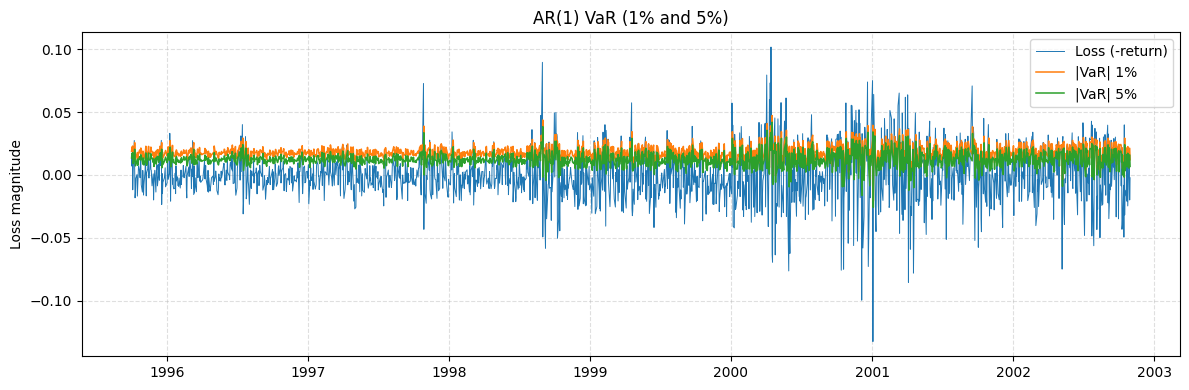

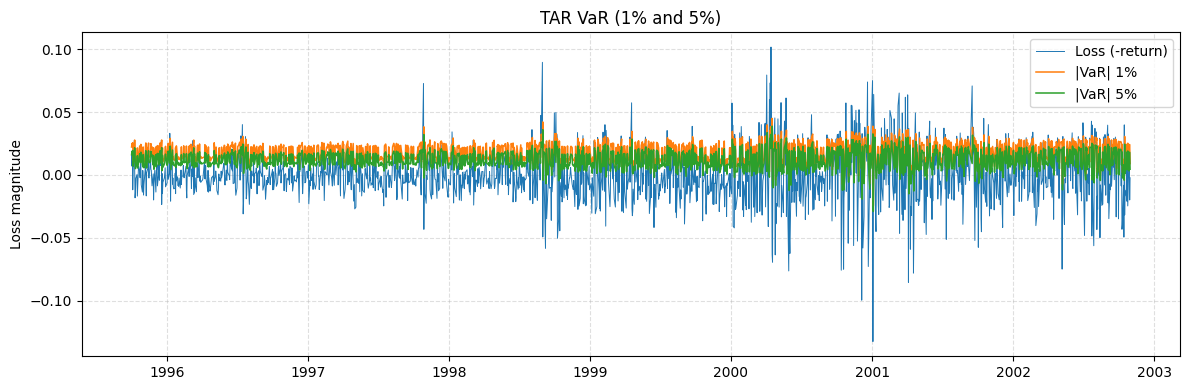

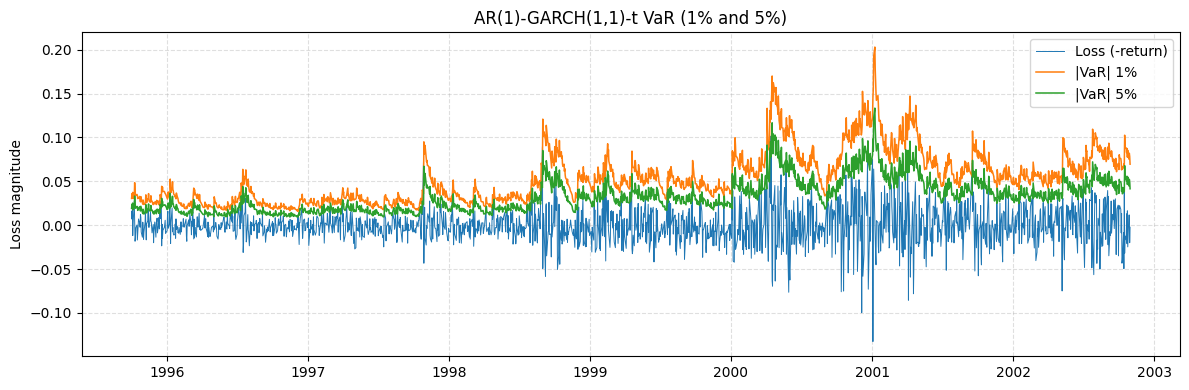


Expected Shortfall summary (positive loss units):
                AR1       TAR     GARCH
Avg ES 1%  0.020371  0.020016  0.068233
Avg ES 5%  0.015697  0.015358  0.046401


In [19]:
# ---------- Question 4: VaR & ES backtest (Oct 1995-Oct 2002) ----------
# Compare AR(1), TAR, and AR(1)-GARCH(1,1)-t.

from scipy.stats import norm, t as student_t, chi2
import numpy as np
import pandas as pd
import statsmodels.api as sm
from arch import arch_model
import matplotlib.pyplot as plt

# ---------- Helpers ----------
EPS = 1e-12

def clip_prob(x, eps=EPS):
    return np.clip(x, eps, 1 - eps)

def var_thresh_normal(mu, sigma, alpha):
    q = norm.ppf(alpha)
    return mu + sigma * q  # return threshold, usually negative

def var_thresh_t(mu, sigma, nu, alpha):
    q = student_t.ppf(alpha, df=nu)
    return mu + sigma * q  # return threshold, usually negative

def es_normal_loss(mu, sigma, alpha):
    z = norm.ppf(alpha)
    # positive loss magnitude conditional on return < VaR
    return sigma * norm.pdf(z) / alpha - mu

def es_t_loss(mu, sigma, nu, alpha):
    q = student_t.ppf(alpha, df=nu)
    c = (student_t.pdf(q, df=nu) / alpha) * ((nu + q**2) / (nu - 1))
    # positive loss magnitude conditional on return < VaR
    return sigma * c - mu

def build_lags(series):
    df = pd.DataFrame({"ret": series})
    df["lag1"] = df["ret"].shift(1)
    return df.dropna()

def tar_design(df):
    i_pos = (df["lag1"] > 0).astype(int)
    X = pd.DataFrame({
        "const": 1.0,
        "lag1_neg": df["lag1"] * (df["lag1"] <= 0),
        "lag1_pos": df["lag1"] * (df["lag1"] > 0),
        "I_pos": i_pos,
    }, index=df.index)
    return X, i_pos

def kupiec_lrt(hits, alpha):
    hits = np.asarray(hits, dtype=int)
    T = len(hits)
    x = int(hits.sum())

    if T == 0:
        return np.nan, np.nan, x, T, np.nan

    p_hat = x / T

    if p_hat in (0, 1):
        lr_uc = 0.0 if np.isclose(p_hat, alpha) else np.inf
    else:
        lr_uc = -2 * (
            (T - x) * np.log((1 - alpha) / (1 - p_hat)) +
            x * np.log(alpha / p_hat)
        )

    p_val = 1 - chi2.cdf(lr_uc, 1) if np.isfinite(lr_uc) else 0.0
    return lr_uc, p_val, x, T, p_hat

def christoffersen_independence(hits):
    hits = np.asarray(hits, dtype=int)

    if len(hits) < 2:
        return np.nan, np.nan

    hp, hn = hits[:-1], hits[1:]
    N00 = int(((hp == 0) & (hn == 0)).sum())
    N01 = int(((hp == 0) & (hn == 1)).sum())
    N10 = int(((hp == 1) & (hn == 0)).sum())
    N11 = int(((hp == 1) & (hn == 1)).sum())

    N0 = N00 + N01
    N1 = N10 + N11
    N = N0 + N1

    if N == 0 or N0 == 0 or N1 == 0:
        return np.nan, np.nan

    pi01 = clip_prob(N01 / N0)
    pi11 = clip_prob(N11 / N1)
    pi1 = clip_prob((N01 + N11) / N)

    ll_indep = (
        (N00 + N10) * np.log(1 - pi1) +
        (N01 + N11) * np.log(pi1)
    )
    ll_markov = (
        N00 * np.log(1 - pi01) + N01 * np.log(pi01) +
        N10 * np.log(1 - pi11) + N11 * np.log(pi11)
    )

    lr_ind = -2 * (ll_indep - ll_markov)
    p_val = 1 - chi2.cdf(lr_ind, 1)
    return lr_ind, p_val

def plot_var(df, ret_col, var1_col, var5_col, title):
    loss = -df[ret_col]
    var1_mag = -df[var1_col]
    var5_mag = -df[var5_col]

    plt.figure(figsize=(12, 4))
    plt.plot(df.index, loss, lw=0.7, label="Loss (-return)")
    plt.plot(df.index, var1_mag, lw=1.1, label="|VaR| 1%")
    plt.plot(df.index, var5_mag, lw=1.1, label="|VaR| 5%")
    plt.title(title)
    plt.ylabel("Loss magnitude")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---------- Window ----------
train_end = "1995-09-30"
eval_start = "1995-10-01"
eval_end = "2002-10-31"

ret = returns.dropna()
ret_train = ret.loc[:train_end]
ret_eval = ret.loc[eval_start:eval_end]
idx = ret_eval.index

# ---------- 1) AR(1) Normal VaR / ES ----------
train_df = build_lags(ret_train)
eval_df = build_lags(pd.concat([ret_train, ret_eval])).loc[eval_start:eval_end]

X_lin = sm.add_constant(train_df["lag1"])
ols_lin = sm.OLS(train_df["ret"], X_lin).fit()

sigma_lin = np.sqrt(ols_lin.resid.var(ddof=int(ols_lin.df_model + 1)))
sigma_lin = max(float(sigma_lin), 1e-8)

X_eval_lin = sm.add_constant(eval_df["lag1"], has_constant="add")
mean_lin = ols_lin.predict(X_eval_lin).reindex(idx)

VaR_lin_1 = pd.Series(var_thresh_normal(mean_lin, sigma_lin, 0.01), index=idx)
VaR_lin_5 = pd.Series(var_thresh_normal(mean_lin, sigma_lin, 0.05), index=idx)

ES_lin_1 = pd.Series(es_normal_loss(mean_lin, sigma_lin, 0.01), index=idx)
ES_lin_5 = pd.Series(es_normal_loss(mean_lin, sigma_lin, 0.05), index=idx)

# ---------- 2) TAR Normal VaR / ES ----------
X_tar_train, i_pos_train = tar_design(train_df)
tar_res = sm.OLS(train_df["ret"], X_tar_train).fit()
resid_tar = tar_res.resid

sigma_tar_pos = resid_tar[i_pos_train == 1].std(ddof=1)
sigma_tar_neg = resid_tar[i_pos_train == 0].std(ddof=1)
sigma_tar_pos = max(float(sigma_tar_pos), 1e-8)
sigma_tar_neg = max(float(sigma_tar_neg), 1e-8)

X_tar_eval, i_pos_eval = tar_design(eval_df)
mean_tar = tar_res.predict(X_tar_eval).reindex(idx)
sigma_tar_series = pd.Series(
    np.where(i_pos_eval == 1, sigma_tar_pos, sigma_tar_neg),
    index=eval_df.index
).reindex(idx)

VaR_tar_1 = pd.Series(var_thresh_normal(mean_tar, sigma_tar_series, 0.01), index=idx)
VaR_tar_5 = pd.Series(var_thresh_normal(mean_tar, sigma_tar_series, 0.05), index=idx)

ES_tar_1 = pd.Series(es_normal_loss(mean_tar, sigma_tar_series, 0.01), index=idx)
ES_tar_5 = pd.Series(es_normal_loss(mean_tar, sigma_tar_series, 0.05), index=idx)

# ---------- 3) AR(1)-GARCH(1,1)-t VaR / ES ----------
# Use a proper expanding-window 1-step-ahead backtest.
ret_full = ret.loc[:eval_end]
ret_full_pct = ret_full * 100

garch_mean_fc = []
garch_sigma_fc = []
garch_dates = []

for date in idx:
    hist = ret.loc[:date].iloc[:-1]  # Information available before date.
    hist_pct = hist * 100

    if len(hist_pct) < 100:
        continue

    am_g = arch_model(
        hist_pct,
        mean="AR",
        lags=1,
        vol="GARCH",
        p=1,
        q=1,
        dist="t"
    )

    res_g = am_g.fit(update_freq=0, disp="off", show_warning=False)
    fc_g = res_g.forecast(horizon=1, reindex=False)

    mu_g = fc_g.mean.iloc[-1, 0] / 100.0
    sigma_g = np.sqrt(fc_g.variance.iloc[-1, 0] / 10000.0)

    garch_mean_fc.append(mu_g)
    garch_sigma_fc.append(max(float(sigma_g), 1e-8))
    garch_dates.append(date)

# Refit once on the full backtest end date to get a representative nu.
am_g_full = arch_model(
    ret_full_pct,
    mean="AR",
    lags=1,
    vol="GARCH",
    p=1,
    q=1,
    dist="t"
)
res_g_full = am_g_full.fit(update_freq=0, disp="off", show_warning=False)
nu_hat = float(res_g_full.params["nu"])

mean_garch = pd.Series(garch_mean_fc, index=garch_dates).reindex(idx)
sigma_garch = pd.Series(garch_sigma_fc, index=garch_dates).reindex(idx)

VaR_garch_1 = pd.Series(var_thresh_t(mean_garch, sigma_garch, nu_hat, 0.01), index=idx)
VaR_garch_5 = pd.Series(var_thresh_t(mean_garch, sigma_garch, nu_hat, 0.05), index=idx)

ES_garch_1 = pd.Series(es_t_loss(mean_garch, sigma_garch, nu_hat, 0.01), index=idx)
ES_garch_5 = pd.Series(es_t_loss(mean_garch, sigma_garch, nu_hat, 0.05), index=idx)

# ---------- 4) Fat-tail AR/TAR VaR with t residual fit ----------
df_lin, loc_lin, scale_lin = student_t.fit(ols_lin.resid)
scale_lin = max(float(scale_lin), 1e-8)

VaR_lin_t_1 = pd.Series(mean_lin + loc_lin + scale_lin * student_t.ppf(0.01, df=df_lin), index=idx)
VaR_lin_t_5 = pd.Series(mean_lin + loc_lin + scale_lin * student_t.ppf(0.05, df=df_lin), index=idx)

df_tar, loc_tar, scale_tar = student_t.fit(resid_tar)
scale_tar = max(float(scale_tar), 1e-8)

VaR_tar_t_1 = pd.Series(mean_tar + loc_tar + scale_tar * student_t.ppf(0.01, df=df_tar), index=idx)
VaR_tar_t_5 = pd.Series(mean_tar + loc_tar + scale_tar * student_t.ppf(0.05, df=df_tar), index=idx)

# ---------- Assemble outputs ----------
var_df = pd.DataFrame({
    "ret": ret_eval.reindex(idx),
    "VaR_AR1_1": VaR_lin_1,
    "VaR_AR1_5": VaR_lin_5,
    "VaR_TAR_1": VaR_tar_1,
    "VaR_TAR_5": VaR_tar_5,
    "VaR_GARCH_1": VaR_garch_1,
    "VaR_GARCH_5": VaR_garch_5,
    "VaR_AR1t_1": VaR_lin_t_1,
    "VaR_AR1t_5": VaR_lin_t_5,
    "VaR_TARt_1": VaR_tar_t_1,
    "VaR_TARt_5": VaR_tar_t_5,
})

es_df = pd.DataFrame({
    "ES_AR1_1": ES_lin_1,
    "ES_AR1_5": ES_lin_5,
    "ES_TAR_1": ES_tar_1,
    "ES_TAR_5": ES_tar_5,
    "ES_GARCH_1": ES_garch_1,
    "ES_GARCH_5": ES_garch_5,
})

print("\nDaily VaR (head):")
print(var_df[[
    "VaR_AR1_1", "VaR_AR1_5",
    "VaR_TAR_1", "VaR_TAR_5",
    "VaR_GARCH_1", "VaR_GARCH_5"
]].head())

print("\nDaily VaR (tail):")
print(var_df[[
    "VaR_AR1_1", "VaR_AR1_5",
    "VaR_TAR_1", "VaR_TAR_5",
    "VaR_GARCH_1", "VaR_GARCH_5"
]].tail())

# ---------- Backtests ----------
var_cols = {
    0.01: [
        ("AR1", "VaR_AR1_1"),
        ("TAR", "VaR_TAR_1"),
        ("GARCH", "VaR_GARCH_1"),
        ("AR1_t", "VaR_AR1t_1"),
        ("TAR_t", "VaR_TARt_1"),
    ],
    0.05: [
        ("AR1", "VaR_AR1_5"),
        ("TAR", "VaR_TAR_5"),
        ("GARCH", "VaR_GARCH_5"),
        ("AR1_t", "VaR_AR1t_5"),
        ("TAR_t", "VaR_TARt_5"),
    ],
}

rows = []
for alpha, models in var_cols.items():
    for name, col in models:
        pair = var_df[["ret", col]].dropna()
        hits = (pair["ret"] < pair[col]).astype(int).values

        lr_uc, p_uc, x, T, p_hat = kupiec_lrt(hits, alpha)
        lr_ind, p_ind = christoffersen_independence(hits)

        lr_cc = (
            lr_uc + lr_ind
            if np.isfinite(lr_uc) and np.isfinite(lr_ind)
            else np.nan
        )
        p_cc = 1 - chi2.cdf(lr_cc, 2) if np.isfinite(lr_cc) else np.nan

        rows.append({
            "alpha": alpha,
            "model": name,
            "T": T,
            "violations": x,
            "hit_rate": p_hat,
            "LR_uc": lr_uc,
            "p_uc": p_uc,
            "LR_ind": lr_ind,
            "p_ind": p_ind,
            "LR_cc": lr_cc,
            "p_cc": p_cc,
        })

backtest_results = pd.DataFrame(rows)
print("\nVaR backtest (Oct 1995–Oct 2002)")
print(backtest_results)

# ---------- Plots ----------
plot_var(var_df, "ret", "VaR_AR1_1", "VaR_AR1_5", "AR(1) VaR (1% and 5%)")
plot_var(var_df, "ret", "VaR_TAR_1", "VaR_TAR_5", "TAR VaR (1% and 5%)")
plot_var(var_df, "ret", "VaR_GARCH_1", "VaR_GARCH_5", "AR(1)-GARCH(1,1)-t VaR (1% and 5%)")

# ---------- ES summary ----------
es_summary = pd.DataFrame({
    "Avg ES 1%": {
        "AR1": ES_lin_1.mean(),
        "TAR": ES_tar_1.mean(),
        "GARCH": ES_garch_1.mean(),
    },
    "Avg ES 5%": {
        "AR1": ES_lin_5.mean(),
        "TAR": ES_tar_5.mean(),
        "GARCH": ES_garch_5.mean(),
    },
}).T

print("\nExpected Shortfall summary (positive loss units):")
print(es_summary)